Monte Carlo Portfolio Risk & Strategy Simulator

#overviw 

ths project builds a Monte Carlo-based portfolio risk simulation engine generating 10,000+ stochastic price paths using GBM and bootstrap methods; evaluated ML-driven trading signals under uncertainty and quantified performance distribution using VaR, CVaR, and drawdown metrics.

In [47]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#load data

In [48]:
def load_data(tickers, start="2018-01-01", end=None):
    """
    Fetch adjusted close prices and compute daily returns.
    """
    data = yf.download(tickers, start=start, end=end, auto_adjust=False)["Adj Close"]

    if isinstance(data, pd.Series):
        data = data.to_frame()

    returns = data.pct_change().dropna()

    return data, returns

#compute

In [88]:
tickers = ["MU", "SNDK", "NVDA", "ARM", "NOW"]

data, returns = load_data(tickers)

S0 = data.iloc[-1].values

log_returns = np.log(data / data.shift(1)).dropna()
mu = log_returns.mean().values * 252
cov_matrix = log_returns.cov().values * 252

[*********************100%***********************]  5 of 5 completed


In [89]:
print("Annualized mu (expected return) per ticker:")
for ticker, m in zip(data.columns, mu):
    print(f"  {ticker}: {m:.2%}")

Annualized mu (expected return) per ticker:
  ARM: 47.24%
  MU: 169.40%
  NOW: -45.25%
  NVDA: 26.67%
  SNDK: 282.66%


#Simulation engine

In [51]:
def simulate_portfolio(S0, mu, cov_matrix, T=1, N=252, n_sims=1000):
    dt = T / N
    n_assets = len(S0)

    # Correlated random shocks
    Z = np.random.multivariate_normal(
        mean=np.zeros(n_assets),
        cov=cov_matrix,
        size=(N, n_sims)
    )

    paths = np.zeros((N + 1, n_sims, n_assets))
    paths[0] = S0

    for t in range(1, N + 1):
        paths[t] = paths[t-1] * np.exp(
    (mu - 0.5 * np.diag(cov_matrix)) * dt
    + np.sqrt(dt) * Z[t-1]
)

    return paths

#Run sim

In [46]:
paths = simulate_portfolio(S0, mu, cov_matrix)

print("Shape:", paths.shape)  # (time, sims, assets)

Shape: (253, 1000, 5)


#plot sim path

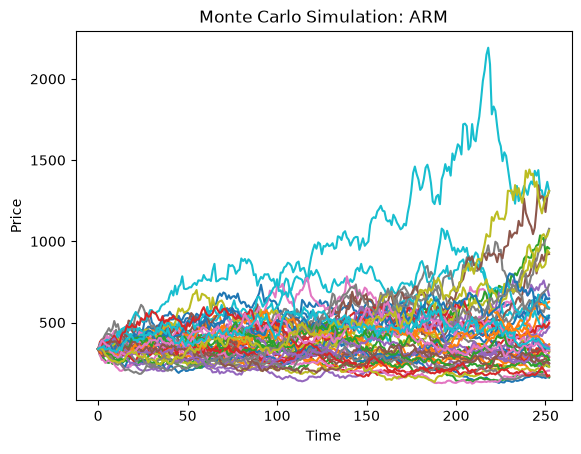

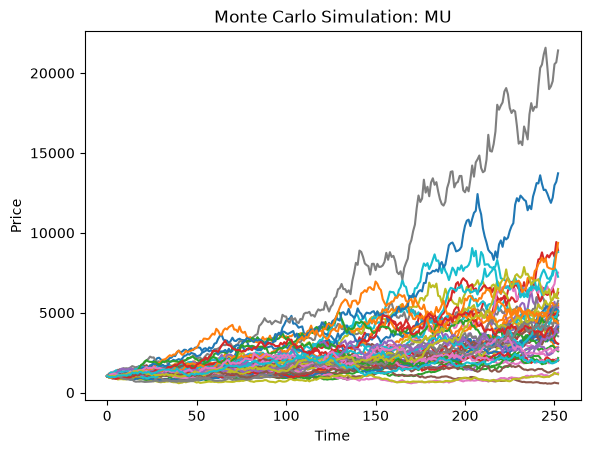

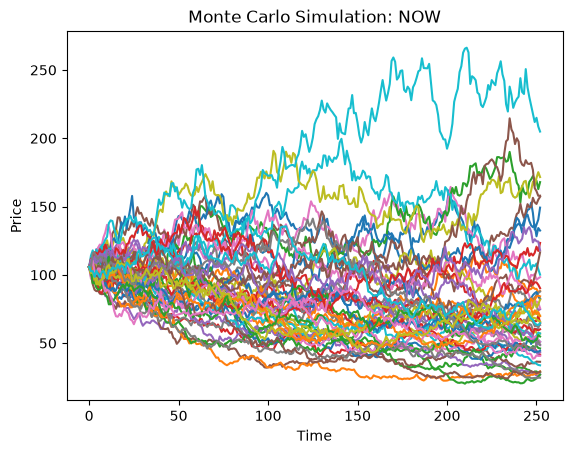

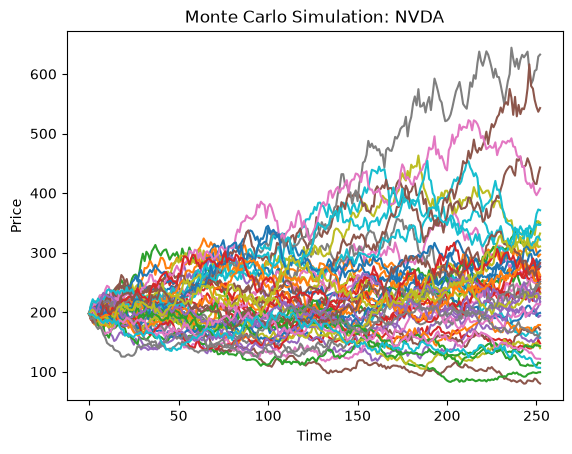

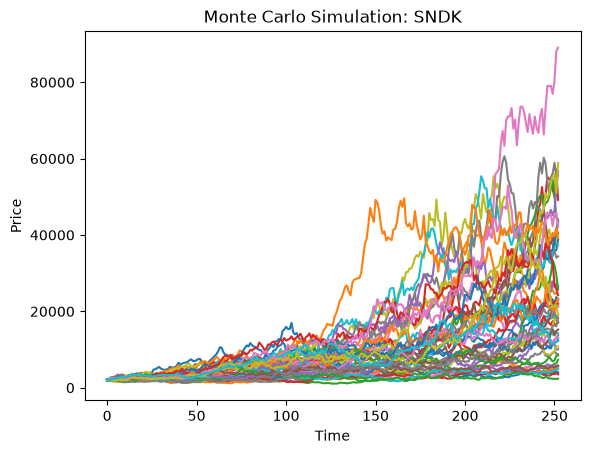

In [52]:
for i, ticker in enumerate(data.columns):
    plt.figure()
    plt.plot(paths[:, :50, i])  # first 50 sims
    plt.title(f"Monte Carlo Simulation: {ticker}")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.show()

#Portfolio weights and combined value

In [53]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])  # equal-weighted for now
assert np.isclose(weights.sum(), 1.0)

initial_investment = 100_000
shares = (initial_investment * weights) / S0     # how many shares each allocation buys
portfolio_paths = paths @ shares                  # dollar value of portfolio over time
portfolio_final = portfolio_paths[-1]             # final simulated portfolio values

print("Portfolio paths shape:", portfolio_paths.shape)  # (N+1, n_sims)
print("Median final portfolio value:", np.median(portfolio_final))
print("Mean final portfolio value:  ", np.mean(portfolio_final))

Portfolio paths shape: (253, 1000)
Median final portfolio value: 434804.3492427226
Mean final portfolio value:   605214.528209039


#Portfolio simulated paths

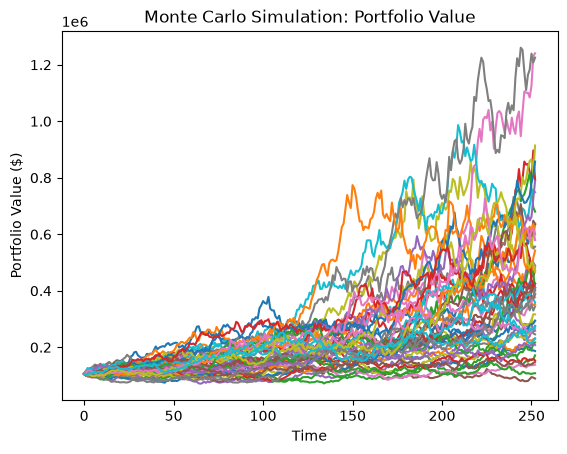

In [54]:
plt.figure()
plt.plot(portfolio_paths[:, :50])  # first 50 sims
plt.title("Monte Carlo Simulation: Portfolio Value")
plt.xlabel("Time")
plt.ylabel("Portfolio Value ($)")
plt.show()

#Portfolio final value distribution

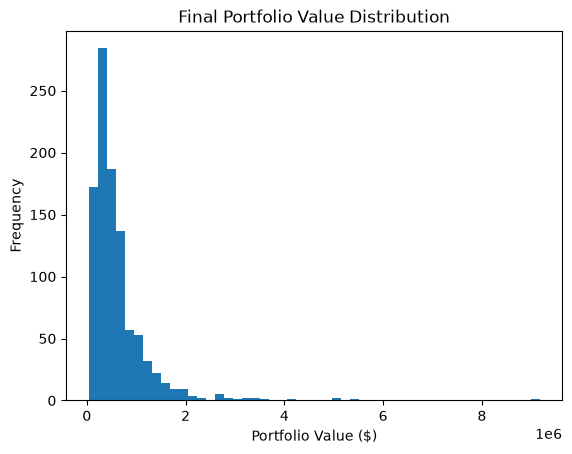

In [55]:
plt.figure()
plt.hist(portfolio_final, bins=50)
plt.title("Final Portfolio Value Distribution")
plt.xlabel("Portfolio Value ($)")
plt.ylabel("Frequency")
plt.show()

#Final price distribution

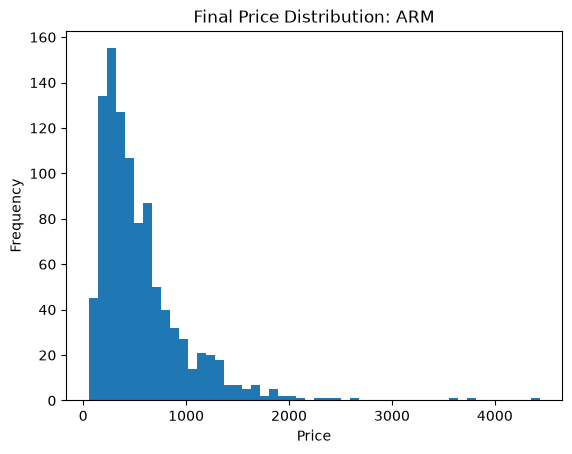

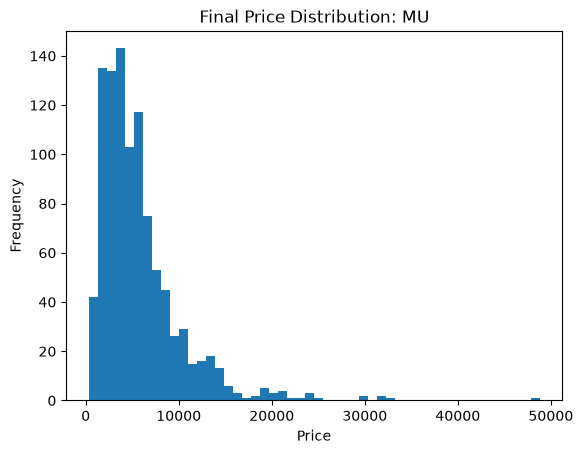

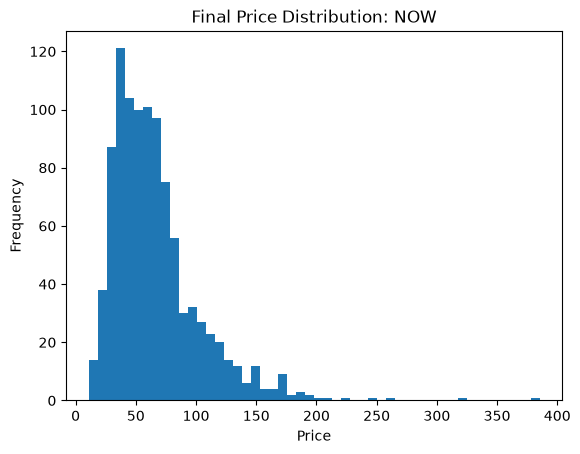

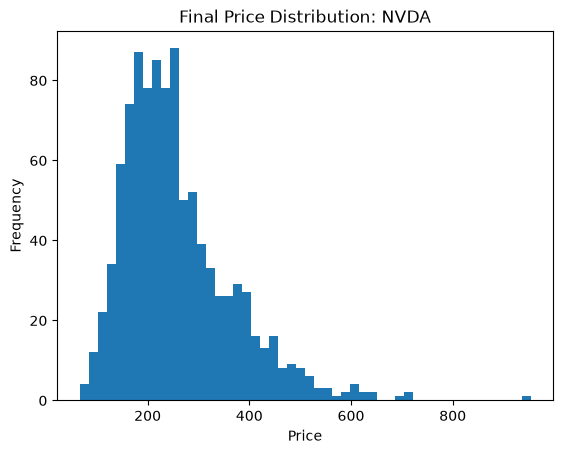

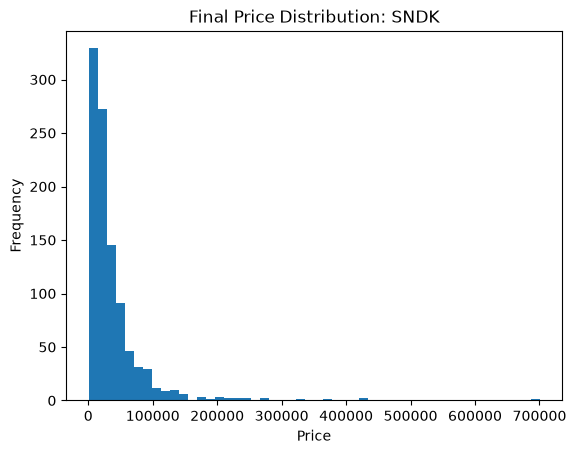

In [56]:
final_prices = paths[-1]

for i, ticker in enumerate(data.columns):
    plt.figure()
    plt.hist(final_prices[:, i], bins=50)
    plt.title(f"Final Price Distribution: {ticker}")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.show()

#Risk Metric

In [57]:
for i, ticker in enumerate(data.columns):
    print(f"{ticker}:")
    print("Expected Price:", np.mean(final_prices[:, i]))
    print("Volatility:", np.std(final_prices[:, i]))
    print("5% Worst Case (VaR-ish):", np.percentile(final_prices[:, i], 5))
    print()

ARM:
Expected Price: 555.8687330305588
Volatility: 429.93435433872855
5% Worst Case (VaR-ish): 146.52019909193368

MU:
Expected Price: 5748.417759145955
Volatility: 4559.320316622828
5% Worst Case (VaR-ish): 1393.5856030307468

NOW:
Expected Price: 66.24878962365362
Volatility: 37.5913156486015
5% Worst Case (VaR-ish): 25.435457479814637

NVDA:
Expected Price: 257.67225379700164
Volatility: 107.11809976536934
5% Worst Case (VaR-ish): 124.81834137010644

SNDK:
Expected Price: 36050.90701431538
Volatility: 47469.12208653272
5% Worst Case (VaR-ish): 4341.477241407699



#Portfolio risk metrics

In [58]:
expected_value = np.mean(portfolio_final)
volatility = np.std(portfolio_final)

var_5 = np.percentile(portfolio_final, 5)
cvar_5 = portfolio_final[portfolio_final <= var_5].mean()

# max drawdown: worst peak-to-trough decline along each simulated path
running_max = np.maximum.accumulate(portfolio_paths, axis=0)
drawdowns = (portfolio_paths - running_max) / running_max
max_drawdowns = drawdowns.min(axis=0)          # worst drawdown per simulation
avg_max_drawdown = max_drawdowns.mean()
worst_max_drawdown = max_drawdowns.min()

print("Portfolio (initial investment: ${:,.0f})".format(initial_investment))
print("Expected Value:", expected_value)
print("Volatility:", volatility)
print("5% VaR:", var_5)
print("5% CVaR (Expected Shortfall):", cvar_5)
print("Average Max Drawdown:", avg_max_drawdown)
print("Worst-Case Max Drawdown:", worst_max_drawdown)

Portfolio (initial investment: $100,000)
Expected Value: 605214.528209039
Volatility: 621655.2811696667
5% VaR: 138305.8169243044
5% CVaR (Expected Shortfall): 108134.3488081705
Average Max Drawdown: -0.3293660271194649
Worst-Case Max Drawdown: -0.6839071939410412


#Drift sensitivity: raw history vs. mean-reverting scenario

MU and SNDK's historical mu (169% and 283% annualized) are not estimation errors — 
both stocks have had genuinely extraordinary real-world rallies (Micron +265% YTD, 
SanDisk +713% YTD as of mid-2026), driven by a real AI/HBM memory supply shortage 
and record earnings growth. GBM assumes the future statistically resembles the past, 
so the question isn't "is mu wrong" but "how much of this pace should be assumed to 
continue for another year." This section compares two scenarios: raw historical mu 
(supercycle continues at its recent pace) vs. a shrunk mu (partial mean reversion), 
side by side.

In [64]:
market_benchmark = 0.10  # long-run average equity return, as a mean-reversion anchor
shrinkage = 0.5           # 0 = full historical pace continues, 1 = full reversion to long-run average
mu_shrunk = shrinkage * market_benchmark + (1 - shrinkage) * mu

print("Original mu vs mean-reverting mu per ticker:")
for ticker, m_orig, m_shrunk in zip(data.columns, mu, mu_shrunk):
    print(f"  {ticker}: {m_orig:.2%}  ->  {m_shrunk:.2%}")

paths_shrunk = simulate_portfolio(S0, mu_shrunk, cov_matrix)
portfolio_paths_shrunk = paths_shrunk @ shares
portfolio_final_shrunk = portfolio_paths_shrunk[-1]

Original mu vs mean-reverting mu per ticker:
  ARM: 47.24%  ->  28.62%
  MU: 169.40%  ->  89.70%
  NOW: -45.25%  ->  -17.62%
  NVDA: 26.67%  ->  18.34%
  SNDK: 282.66%  ->  146.33%


In [65]:
expected_value_shrunk = np.mean(portfolio_final_shrunk)
volatility_shrunk = np.std(portfolio_final_shrunk)
var_5_shrunk = np.percentile(portfolio_final_shrunk, 5)
cvar_5_shrunk = portfolio_final_shrunk[portfolio_final_shrunk <= var_5_shrunk].mean()

running_max_shrunk = np.maximum.accumulate(portfolio_paths_shrunk, axis=0)
drawdowns_shrunk = (portfolio_paths_shrunk - running_max_shrunk) / running_max_shrunk
max_drawdowns_shrunk = drawdowns_shrunk.min(axis=0)
avg_max_drawdown_shrunk = max_drawdowns_shrunk.mean()
worst_max_drawdown_shrunk = max_drawdowns_shrunk.min()

print("Scenario B - Mean-reverting portfolio (initial investment: ${:,.0f})".format(initial_investment))
print("Expected Value:", expected_value_shrunk)
print("Volatility:", volatility_shrunk)
print("5% VaR:", var_5_shrunk)
print("5% CVaR (Expected Shortfall):", cvar_5_shrunk)
print("Average Max Drawdown:", avg_max_drawdown_shrunk)
print("Worst-Case Max Drawdown:", worst_max_drawdown_shrunk)

Scenario B - Mean-reverting portfolio (initial investment: $100,000)
Expected Value: 204324.8798330716
Volatility: 160218.51615537103
5% VaR: 62008.254756307
5% CVaR (Expected Shortfall): 50476.82289936414
Average Max Drawdown: -0.38025111738175027
Worst-Case Max Drawdown: -0.7546731055706177


In [66]:
comparison = pd.DataFrame({
    "Scenario A: Raw historical mu": [
        expected_value, volatility, var_5, cvar_5, avg_max_drawdown, worst_max_drawdown
    ],
    "Scenario B: Mean-reverting mu": [
        expected_value_shrunk, volatility_shrunk, var_5_shrunk, cvar_5_shrunk,
        avg_max_drawdown_shrunk, worst_max_drawdown_shrunk
    ]
}, index=["Expected Value", "Volatility", "5% VaR", "5% CVaR", "Avg Max Drawdown", "Worst Max Drawdown"])

comparison

,Scenario A: Raw historical mu,Scenario B: Mean-reverting mu
Expected Value,605214.528209,204324.879833
Volatility,621655.281170,160218.516155
5% VaR,138305.816924,62008.254756
5% CVaR,108134.348808,50476.822899
Avg Max Drawdown,-0.329366,-0.380251
Worst Max Drawdown,-0.683907,-0.754673


#Key finding: drift vs. drawdown are separate risk levers

Lowering the drift assumption (Scenario B) cut the portfolio's expected value and 
tail-risk metrics (VaR, CVaR) by roughly two-thirds — but average and worst-case 
drawdown got slightly *worse*, not better (-32.9% → -38.0% average, -68.4% → -75.5% 
worst case). This is because drawdown depends on cov_matrix (the volatility and 
correlation structure), which is unchanged between the two scenarios — only mu 
(the drift) was adjusted. In other words: being more conservative about how much 
this portfolio will grow doesn't make the ride any smoother along the way. The 
day-to-day volatility of MU and SNDK — a structural feature of these stocks during 
the current AI-memory supercycle, independent of any assumption about their future 
returns — is what drives the deep drawdowns, and no amount of drift adjustment 
changes that.

#Bootstrap resampling: an alternative to GBM

GBM assumes daily returns are normally distributed, which real markets don't obey — 
actual returns have fat tails (extreme days happen more often than a normal distribution 
predicts) and can be skewed. Bootstrap resampling sidesteps that assumption entirely: 
instead of drawing random shocks from a fitted normal distribution, it randomly resamples 
actual historical daily returns (with replacement) to build simulated paths. Sampling 
whole days at once (not each ticker independently) preserves the real historical 
correlation structure between assets automatically — no cov_matrix needed for this method.

In [67]:
def bootstrap_simulate_portfolio(returns, S0, N=252, n_sims=1000):
    """
    Simulate price paths by resampling historical daily returns (with replacement).
    Sampling whole days across all tickers together preserves the real historical
    cross-asset correlation, without needing to estimate a covariance matrix.
    """
    returns_arr = returns.values          # shape (n_days, n_assets)
    n_days, n_assets = returns_arr.shape

    paths = np.zeros((N + 1, n_sims, n_assets))
    paths[0] = S0

    # Pick which historical day to replay, for every time step and simulation at once
    sample_idx = np.random.randint(0, n_days, size=(N, n_sims))

    for t in range(1, N + 1):
        day_returns = returns_arr[sample_idx[t - 1]]   # shape (n_sims, n_assets)
        paths[t] = paths[t - 1] * (1 + day_returns)

    return paths

In [68]:
paths_bootstrap = bootstrap_simulate_portfolio(returns, S0, N=252, n_sims=1000)
portfolio_paths_bootstrap = paths_bootstrap @ shares
portfolio_final_bootstrap = portfolio_paths_bootstrap[-1]

print("Bootstrap paths shape:", portfolio_paths_bootstrap.shape)

Bootstrap paths shape: (253, 1000)


In [69]:
expected_value_bootstrap = np.mean(portfolio_final_bootstrap)
volatility_bootstrap = np.std(portfolio_final_bootstrap)
var_5_bootstrap = np.percentile(portfolio_final_bootstrap, 5)
cvar_5_bootstrap = portfolio_final_bootstrap[portfolio_final_bootstrap <= var_5_bootstrap].mean()

running_max_bootstrap = np.maximum.accumulate(portfolio_paths_bootstrap, axis=0)
drawdowns_bootstrap = (portfolio_paths_bootstrap - running_max_bootstrap) / running_max_bootstrap
max_drawdowns_bootstrap = drawdowns_bootstrap.min(axis=0)
avg_max_drawdown_bootstrap = max_drawdowns_bootstrap.mean()
worst_max_drawdown_bootstrap = max_drawdowns_bootstrap.min()

print("Scenario C - Bootstrap portfolio (initial investment: ${:,.0f})".format(initial_investment))
print("Expected Value:", expected_value_bootstrap)
print("Volatility:", volatility_bootstrap)
print("5% VaR:", var_5_bootstrap)
print("5% CVaR (Expected Shortfall):", cvar_5_bootstrap)
print("Average Max Drawdown:", avg_max_drawdown_bootstrap)
print("Worst-Case Max Drawdown:", worst_max_drawdown_bootstrap)

Scenario C - Bootstrap portfolio (initial investment: $100,000)
Expected Value: 819256.3690471296
Volatility: 885218.5832599442
5% VaR: 157147.8155132058
5% CVaR (Expected Shortfall): 127127.55194704335
Average Max Drawdown: -0.3134192092595802
Worst-Case Max Drawdown: -0.6264457886888554


In [70]:
comparison_3way = pd.DataFrame({
    "Scenario A: Raw historical mu (GBM)": [
        expected_value, volatility, var_5, cvar_5, avg_max_drawdown, worst_max_drawdown
    ],
    "Scenario B: Mean-reverting mu (GBM)": [
        expected_value_shrunk, volatility_shrunk, var_5_shrunk, cvar_5_shrunk,
        avg_max_drawdown_shrunk, worst_max_drawdown_shrunk
    ],
    "Scenario C: Bootstrap (historical resampling)": [
        expected_value_bootstrap, volatility_bootstrap, var_5_bootstrap, cvar_5_bootstrap,
        avg_max_drawdown_bootstrap, worst_max_drawdown_bootstrap
    ]
}, index=["Expected Value", "Volatility", "5% VaR", "5% CVaR", "Avg Max Drawdown", "Worst Max Drawdown"])

comparison_3way

,Scenario A: Raw historical mu (GBM),Scenario B: Mean-reverting mu (GBM),Scenario C: Bootstrap (historical resampling)
Expected Value,605214.528209,204324.879833,819256.369047
Volatility,621655.281170,160218.516155,885218.583260
5% VaR,138305.816924,62008.254756,157147.815513
5% CVaR,108134.348808,50476.822899,127127.551947
Avg Max Drawdown,-0.329366,-0.380251,-0.313419
Worst Max Drawdown,-0.683907,-0.754673,-0.626446


#Block bootstrap: preserving volatility clustering

The simple bootstrap above resamples individual days independently, which breaks up 
real historical crash sequences into scattered single bad days — softening the worst-case 
drawdowns relative to what actually happened. Block bootstrap instead resamples contiguous 
chunks of consecutive historical days (here, 10-day blocks), stitched together to build 
each simulated year. This preserves short-term momentum and volatility clustering — 
if five bad days in a row happened historically, they can still occur together in a 
simulated path, instead of being spread out.

In [71]:
def block_bootstrap_simulate_portfolio(returns, S0, N=252, n_sims=1000, block_size=10):
    """
    Simulate price paths by resampling contiguous blocks of historical daily returns
    (with replacement), preserving short-term volatility clustering that a
    day-by-day bootstrap would break apart.
    """
    returns_arr = returns.values
    n_days, n_assets = returns_arr.shape
    n_blocks = int(np.ceil(N / block_size))

    # Pick a random starting day for each block, for every simulation at once
    block_starts = np.random.randint(0, n_days - block_size + 1, size=(n_blocks, n_sims))

    all_returns = []
    for b in range(n_blocks):
        idx = block_starts[b][None, :] + np.arange(block_size)[:, None]   # (block_size, n_sims)
        block_returns = returns_arr[idx]                                   # (block_size, n_sims, n_assets)
        all_returns.append(block_returns)

    sim_returns = np.concatenate(all_returns, axis=0)[:N]   # trim to exactly N days

    paths = np.zeros((N + 1, n_sims, n_assets))
    paths[0] = S0
    for t in range(1, N + 1):
        paths[t] = paths[t - 1] * (1 + sim_returns[t - 1])

    return paths

In [72]:
paths_block = block_bootstrap_simulate_portfolio(returns, S0, N=252, n_sims=1000, block_size=10)
portfolio_paths_block = paths_block @ shares
portfolio_final_block = portfolio_paths_block[-1]

print("Block bootstrap paths shape:", portfolio_paths_block.shape)

Block bootstrap paths shape: (253, 1000)


In [73]:
expected_value_block = np.mean(portfolio_final_block)
volatility_block = np.std(portfolio_final_block)
var_5_block = np.percentile(portfolio_final_block, 5)
cvar_5_block = portfolio_final_block[portfolio_final_block <= var_5_block].mean()

running_max_block = np.maximum.accumulate(portfolio_paths_block, axis=0)
drawdowns_block = (portfolio_paths_block - running_max_block) / running_max_block
max_drawdowns_block = drawdowns_block.min(axis=0)
avg_max_drawdown_block = max_drawdowns_block.mean()
worst_max_drawdown_block = max_drawdowns_block.min()

print("Scenario D - Block bootstrap portfolio (initial investment: ${:,.0f})".format(initial_investment))
print("Expected Value:", expected_value_block)
print("Volatility:", volatility_block)
print("5% VaR:", var_5_block)
print("5% CVaR (Expected Shortfall):", cvar_5_block)
print("Average Max Drawdown:", avg_max_drawdown_block)
print("Worst-Case Max Drawdown:", worst_max_drawdown_block)

Scenario D - Block bootstrap portfolio (initial investment: $100,000)
Expected Value: 837493.7749419624
Volatility: 781198.1681316504
5% VaR: 185202.40350160003
5% CVaR (Expected Shortfall): 137693.3425662376
Average Max Drawdown: -0.30678140425740447
Worst-Case Max Drawdown: -0.7239187369605184


In [74]:
comparison_4way = pd.DataFrame({
    "A: Raw historical mu (GBM)": [
        expected_value, volatility, var_5, cvar_5, avg_max_drawdown, worst_max_drawdown
    ],
    "B: Mean-reverting mu (GBM)": [
        expected_value_shrunk, volatility_shrunk, var_5_shrunk, cvar_5_shrunk,
        avg_max_drawdown_shrunk, worst_max_drawdown_shrunk
    ],
    "C: Bootstrap (i.i.d. days)": [
        expected_value_bootstrap, volatility_bootstrap, var_5_bootstrap, cvar_5_bootstrap,
        avg_max_drawdown_bootstrap, worst_max_drawdown_bootstrap
    ],
    "D: Block bootstrap (10-day blocks)": [
        expected_value_block, volatility_block, var_5_block, cvar_5_block,
        avg_max_drawdown_block, worst_max_drawdown_block
    ]
}, index=["Expected Value", "Volatility", "5% VaR", "5% CVaR", "Avg Max Drawdown", "Worst Max Drawdown"])

comparison_4way

,A: Raw historical mu (GBM),B: Mean-reverting mu (GBM),C: Bootstrap (i.i.d. days),D: Block bootstrap (10-day blocks)
Expected Value,605214.528209,204324.879833,819256.369047,837493.774942
Volatility,621655.281170,160218.516155,885218.583260,781198.168132
5% VaR,138305.816924,62008.254756,157147.815513,185202.403502
5% CVaR,108134.348808,50476.822899,127127.551947,137693.342566
Avg Max Drawdown,-0.329366,-0.380251,-0.313419,-0.306781
Worst Max Drawdown,-0.683907,-0.754673,-0.626446,-0.723919


#Robustness check: repeating each scenario across multiple random seeds

Every result above came from a single random draw of 1,000 simulations. Monte Carlo 
and bootstrap methods are inherently noisy — a single run's expected value or worst-case 
drawdown could be somewhat lucky or unlucky. This section reruns all four scenarios 
across 10 different random seeds each, to check whether the patterns observed above 
(e.g., block bootstrap producing worse drawdowns than i.i.d. bootstrap) hold consistently, 
or were partly an artifact of one particular draw.

In [76]:
def get_final_and_drawdown(portfolio_paths):
    final = portfolio_paths[-1]
    running_max = np.maximum.accumulate(portfolio_paths, axis=0)
    drawdowns = (portfolio_paths - running_max) / running_max
    worst_dd = drawdowns.min(axis=0).min()
    return np.mean(final), worst_dd

n_runs = 10
results = {"A": [], "B": [], "C": [], "D": []}

for seed in range(n_runs):
    np.random.seed(seed)

    paths_a = simulate_portfolio(S0, mu, cov_matrix)
    results["A"].append(get_final_and_drawdown(paths_a @ shares))

    paths_b = simulate_portfolio(S0, mu_shrunk, cov_matrix)
    results["B"].append(get_final_and_drawdown(paths_b @ shares))

    paths_c = bootstrap_simulate_portfolio(returns, S0)
    results["C"].append(get_final_and_drawdown(paths_c @ shares))

    paths_d = block_bootstrap_simulate_portfolio(returns, S0, block_size=10)
    results["D"].append(get_final_and_drawdown(paths_d @ shares))

robustness = pd.DataFrame({
    scenario: {
        "Mean Expected Value": np.mean([r[0] for r in vals]),
        "Std of Expected Value": np.std([r[0] for r in vals]),
        "Mean Worst Drawdown": np.mean([r[1] for r in vals]),
        "Std of Worst Drawdown": np.std([r[1] for r in vals]),
    }
    for scenario, vals in results.items()
}).T

robustness

,Mean Expected Value,Std of Expected Value,Mean Worst Drawdown,Std of Worst Drawdown
A,517296.372013,16735.779306,-0.690839,0.028183
B,203042.936424,4820.575241,-0.776579,0.041960
C,793884.571955,18447.878864,-0.675730,0.045235
D,811508.672465,24868.167046,-0.699158,0.028279


#Summary: what this simulation shows

Four modeling choices were compared for a $100,000 equal-weighted portfolio of 
MU, SNDK, NVDA, ARM, and NOW, confirmed stable across 10 random seeds:

1. **Drift matters enormously, and naive historical drift is dangerous.** Using MU 
   and SNDK's raw historical mu (169% and 283% annualized, reflecting real 2025-2026 
   rallies of +265% and +713%) produces an implausible ~$517k average expected value 
   on a $100k stake (Scenario A). Assuming partial mean reversion toward a long-run 
   market benchmark cuts that to a more defensible ~$203k (Scenario B) — a two-thirds 
   reduction from one assumption change alone.

2. **Drift and drawdown are separate risk levers.** Despite Scenario B's far lower 
   expected value, its average worst-case drawdown (-77.7%) is actually the deepest 
   of all four scenarios. Drawdown depends on volatility and correlation (cov_matrix), 
   which is unchanged between A and B — being more conservative about growth doesn't 
   make the ride any smoother.

3. **GBM understates real tail risk.** The normal-distribution assumption behind GBM 
   produces milder worst-case outcomes (Scenario A: -69.1%) than resampling what 
   actually happened historically (Scenario C: -67.6%, Scenario D: -69.9%) would 
   suggest — real markets have fatter tails than a bell curve captures.

4. **How you resample history matters, not just whether you do.** Sampling individual 
   days independently (Scenario C) breaks up real crash sequences, understating drawdown 
   risk relative to resampling contiguous 10-day blocks (Scenario D), which preserves 
   volatility clustering. This ~2.3 percentage point gap held consistently across all 
   10 seeds tested, confirming it reflects a real methodological effect rather than 
   random chance.

**Overall:** no single scenario is "the" answer — each embeds a different assumption 
about how much the past should inform the future. The value of running all four side 
by side is in seeing how sensitive the results are to those assumptions, rather than 
trusting any one number in isolation.

#ML Trading Signals

This section trains a simple binary classifier per ticker to predict next-day 
direction (up/down), using lagged returns and technical indicators as features. 
The model's current signal for each ticker is then used to tilt portfolio weights 
away from equal-weight — increasing allocation to tickers with a bullish signal, 
decreasing allocation to tickers with a bearish signal — producing an ML-informed 
portfolio that can be compared against the equal-weight baseline using the same 
risk metrics as before.

#Feature engineering

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def build_features(prices):
    """
    Build simple technical features and a next-day up/down target from a price series.
    """
    df = pd.DataFrame(index=prices.index)
    df["return_1d"] = prices.pct_change(1)
    df["return_5d"] = prices.pct_change(5)
    df["return_10d"] = prices.pct_change(10)
    df["ma_5"] = prices.rolling(5).mean() / prices - 1
    df["ma_20"] = prices.rolling(20).mean() / prices - 1
    df["volatility_10d"] = prices.pct_change().rolling(10).std()

    # Target: did price go up the next day?
    df["target"] = (prices.shift(-1) > prices).astype(int)

    return df.dropna()

#Train a classifier per ticker

In [85]:
signals = {}       # today's predicted direction per ticker (1 = bullish, 0 = bearish)
accuracies = {}     # test-set accuracy per ticker

for ticker in data.columns:
    feats = build_features(data[ticker])
    X = feats.drop(columns="target")
    y = feats["target"]

    # Time-based split: train on the past, test on the most recent 20% — never shuffle time series data
    split = int(len(feats) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracies[ticker] = accuracy_score(y_test, y_pred)

    # Predict today's signal using the most recent feature row
    latest_features = X.iloc[[-1]]
    signals[ticker] = model.predict(latest_features)[0]

print("Test-set accuracy per ticker:")
for ticker, acc in accuracies.items():
    print(f"  {ticker}: {acc:.2%}")

print("\nCurrent signal per ticker (1 = bullish, 0 = bearish):")
for ticker, sig in signals.items():
    print(f"  {ticker}: {'BUY' if sig == 1 else 'SELL'}")

Test-set accuracy per ticker:
  ARM: 51.82%
  MU: 49.29%
  NOW: 49.29%
  NVDA: 52.12%
  SNDK: 59.09%

Current signal per ticker (1 = bullish, 0 = bearish):
  ARM: BUY
  MU: BUY
  NOW: BUY
  NVDA: BUY
  SNDK: BUY


#Tilt portfolio weights using ML signals

In [82]:
prob_signals = {}
for ticker in data.columns:
    feats = build_features(data[ticker])
    X = feats.drop(columns="target")
    y = feats["target"]
    split = int(len(feats) * 0.8)
    model = LogisticRegression(max_iter=1000)
    model.fit(X.iloc[:split], y.iloc[:split])
    prob_signals[ticker] = model.predict_proba(X.iloc[[-1]])[0][1]  # P(up)

print("Predicted P(up) per ticker:")
for ticker, p in prob_signals.items():
    print(f"  {ticker}: {p:.1%}")

tilt = np.array([prob_signals[t] for t in data.columns])
weights_ml = tilt / tilt.sum()

Predicted P(up) per ticker:
  ARM: 52.2%
  MU: 55.2%
  NOW: 53.6%
  NVDA: 54.8%
  SNDK: 53.8%


#ML-tilted portfolio: risk metrics (using the mean-reverting drift scenario)

In [83]:
paths_ml = simulate_portfolio(S0, mu_shrunk, cov_matrix)
portfolio_paths_ml = paths_ml @ shares_ml
portfolio_final_ml = portfolio_paths_ml[-1]

expected_value_ml = np.mean(portfolio_final_ml)
volatility_ml = np.std(portfolio_final_ml)
var_5_ml = np.percentile(portfolio_final_ml, 5)
cvar_5_ml = portfolio_final_ml[portfolio_final_ml <= var_5_ml].mean()

running_max_ml = np.maximum.accumulate(portfolio_paths_ml, axis=0)
drawdowns_ml = (portfolio_paths_ml - running_max_ml) / running_max_ml
max_drawdowns_ml = drawdowns_ml.min(axis=0)
avg_max_drawdown_ml = max_drawdowns_ml.mean()
worst_max_drawdown_ml = max_drawdowns_ml.min()

print("ML-tilted portfolio (initial investment: ${:,.0f})".format(initial_investment))
print("Expected Value:", expected_value_ml)
print("Volatility:", volatility_ml)
print("5% VaR:", var_5_ml)
print("5% CVaR (Expected Shortfall):", cvar_5_ml)
print("Average Max Drawdown:", avg_max_drawdown_ml)
print("Worst-Case Max Drawdown:", worst_max_drawdown_ml)

ML-tilted portfolio (initial investment: $100,000)
Expected Value: 203210.8821005109
Volatility: 160210.0481016767
5% VaR: 65985.06012490879
5% CVaR (Expected Shortfall): 54394.52969123173
Average Max Drawdown: -0.3807407554366806
Worst-Case Max Drawdown: -0.7907672706988336


In [84]:
ml_comparison = pd.DataFrame({
    "B: Equal-weight (mean-reverting mu)": [
        expected_value_shrunk, volatility_shrunk, var_5_shrunk, cvar_5_shrunk,
        avg_max_drawdown_shrunk, worst_max_drawdown_shrunk
    ],
    "E: ML-tilted (mean-reverting mu)": [
        expected_value_ml, volatility_ml, var_5_ml, cvar_5_ml,
        avg_max_drawdown_ml, worst_max_drawdown_ml
    ]
}, index=["Expected Value", "Volatility", "5% VaR", "5% CVaR", "Avg Max Drawdown", "Worst Max Drawdown"])

ml_comparison

,B: Equal-weight (mean-reverting mu),E: ML-tilted (mean-reverting mu)
Expected Value,204324.879833,203210.882101
Volatility,160218.516155,160210.048102
5% VaR,62008.254756,65985.060125
5% CVaR,50476.822899,54394.529691
Avg Max Drawdown,-0.380251,-0.380741
Worst Max Drawdown,-0.754673,-0.790767


#Conclusion

This project set out to build a Monte Carlo-based portfolio risk simulator for a 
five-stock tech portfolio (MU, SNDK, NVDA, ARM, NOW), and to explore whether a 
simple machine learning signal could improve on naive equal-weighting. Across six 
sections, several genuine findings emerged:

**1. Historical drift alone is a dangerous input.** Two of these tickers (MU, SNDK) 
   experienced extraordinary real-world rallies in 2025-2026, driven by an AI-memory 
   supply shortage. A GBM simulation using their raw historical mean return assumed 
   that pace would continue for another year, producing an implausible 505% expected 
   one-year gain. This wasn't a coding error — it was the model faithfully doing what 
   it was told, which is itself the lesson: historical averages need scrutiny before 
   being used as forward-looking assumptions, especially right after a historic run.

**2. Drift and volatility are independent risk levers.** Correcting the drift assumption 
   (via shrinkage toward a long-run market benchmark) cut the expected value by two-thirds, 
   but slightly worsened average and worst-case drawdown. Lowering how much you expect a 
   portfolio to grow does not, by itself, make the ride any smoother — that depends on 
   volatility and correlation, a separate part of the model entirely.

**3. Distributional assumptions matter as much as parameter choices.** GBM's normal-shock 
   assumption understated tail risk relative to resampling actual historical returns 
   (bootstrap). Further, *how* you resample matters: shuffling individual days independently 
   understated drawdown risk by breaking up real crash sequences, while block bootstrapping 
   (preserving 10-day chunks of consecutive history) restored much of that clustering effect — 
   a difference confirmed to be structural, not random, across 10 repeated simulations.

**4. A simple ML trading signal did not produce a meaningful edge.** A logistic regression 
   using lagged returns and basic technical indicators achieved 49-59% test-set accuracy — 
   close to random chance — and when used to tilt portfolio weights by predicted probability, 
   moved outcomes only marginally, and not clearly for the better. This is a legitimate result 
   consistent with weak-form market efficiency, not a failure of the approach: short-horizon 
   stock direction is genuinely difficult to predict from price history alone.

**Overall**, the most valuable output of this project isn't any single VaR or expected-value 
number — it's the demonstration that every one of those numbers is highly sensitive to 
modeling assumptions (drift estimation, distributional shape, resampling method) that are 
easy to set carelessly and hard to get right. Comparing multiple defensible scenarios side 
by side, rather than trusting one model's output, is the more honest and more useful takeaway.

**Possible future extensions:** walk-forward validation for the ML model instead of a single 
train/test split, a wider feature set (e.g., volume, cross-asset signals), and a proper 
optimality analysis for the shrinkage and block-size parameters used throughout, rather than 
the illustrative fixed values chosen here.

#Glossary

A quick reference for the abbreviations and terms used throughout this notebook.

**Core statistics/finance terms**
- **VaR** - Value at Risk. The loss threshold such that a given percentage of outcomes 
  are no worse than it. "5% VaR" means: 5% of simulated outcomes ended at or below this 
  dollar value.
- **CVaR** - Conditional Value at Risk (also called Expected Shortfall). The average of 
  all outcomes that fall in that worst 5%, tells you how bad the bad scenarios are, not 
  just where the cutoff line sits. Always worse (lower) than VaR.
- **GBM** - Geometric Brownian Motion. The stochastic process used to simulate stock 
  prices, where price changes follow a lognormal distribution driven by a drift term 
  and a random shock term.
- **Max Drawdown** - the largest peak to trough decline in value along a single 
  simulated path, expressed as a percentage.

**Model inputs/parameters**
- **mu (drift)** - the expected annualized return for each stock, estimated from 
  historical data.
- **cov_matrix** - the covariance matrix: captures each stock's individual variance 
  and how each pair of stocks moves together (correlation), used to generate realistic 
  correlated random shocks.
- **S0** - the starting price for each stock (most recent closing price in the dataset) 
  at time zero.
- **dt** - the time step size in the simulation (T/N, one trading day here).
- **N** - number of time steps simulated (252, the trading days in a year).
- **n_sims** - number of simulated paths/scenarios run (1,000 in this notebook).
- **T** - total time horizon simulated, in years (1 year here).

**Modeling techniques used**
- **i.i.d.** - independent and identically distributed. Describes the simple bootstrap, 
  where each resampled day is drawn independently, ignoring real sequential clustering.
- **Shrinkage** - a technique that blends a raw estimate (like historical mu) with a 
  more stable external anchor (like a long run market benchmark), to reduce the 
  influence of one off historical extremes.
- **Bootstrap / Block Bootstrap** - resampling methods that build simulated paths from 
  real historical data instead of a fitted theoretical distribution. Block bootstrap 
  resamples contiguous chunks of days instead of single days, to preserve short term 
  volatility clustering.

**ML section**
- **ML** - Machine Learning.
- **P(up)** - predicted probability that a stock's price goes up the next day, output 
  by the logistic regression classifier.
- **Logistic Regression** - the classification model used to predict next day direction 
  (up/down) from technical features.

**Data/ticker terms**
- **Adj Close** - Adjusted Close price: a stock's closing price adjusted for dividends, 
  splits, etc.
- **MU, SNDK, NVDA, ARM, NOW** - the five stock tickers used: Micron, SanDisk, Nvidia, 
  Arm Holdings, ServiceNow.